# MLE · MAP · ERM · NLL — The Same Idea Wearing Different Hats

These acronyms feel like a soup because textbooks introduce them in different chapters as if they were unrelated. They are **not** unrelated. Almost all of supervised learning is one sentence:

> **Pick the model parameters that make the observed data least surprising.**

Every term below is a different lens on that one sentence. This notebook's job is to make the connections click, then ground them in the **two scenarios you'll be asked about in a quant interview** — regression and classification — and show that linear regression and logistic regression are *literally the same recipe* with one ingredient swapped.

---

### The 30-second map (read this first, re-read it at the end)

| Acronym | Full name | What it actually is |
|---|---|---|
| **MLE** | Maximum Likelihood Estimation | Choose $\theta$ that maximizes the probability of the data. The starting point. |
| **NLL** | Negative Log Likelihood | The **loss function** you minimize to *do* MLE. (Maximizing likelihood = minimizing $-\log$ likelihood.) |
| **MAP** | Maximum A Posteriori | MLE **plus a prior belief** about $\theta$. Mathematically = MLE + regularization. |
| **ERM** | Empirical Risk Minimization | The **umbrella framework**: minimize average loss on your data. MLE/NLL is a *special case* of ERM. |

> **Key insight:** MLE and ERM are the same optimization from two cultures — statisticians say "maximize likelihood," ML people say "minimize average loss." Take $-\log$ of the first and you get the second. NLL is the bridge. MAP just adds a penalty term.

🎯 **Quant interview flag:** "Derive logistic regression's loss" and "why is MSE the right loss for regression?" are *extremely* common. Both answers are "because of MLE." By the end of this notebook you'll be able to derive both from scratch.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

rng = default_rng(0)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

# our 5-color palette, used everywhere
PALETTE = ["steelblue", "tomato", "mediumseagreen", "darkorange", "navy"]
print("setup ready")

setup ready


---
## 1 · Likelihood — the one concept everything is built on

**Why this first?** Every acronym is a verb applied to *likelihood*. If you understand likelihood, the rest is bookkeeping.

Imagine you have a model with parameters $\theta$ (e.g. the slope and intercept of a line, or the weights of a classifier). The model assigns a **probability** to each possible data outcome. The **likelihood** is that probability, but read backwards:

$$
\mathcal{L}(\theta) = p(\text{data} \mid \theta)
$$

> **Probability vs. likelihood — the classic confusion:** Same formula, opposite question.
> - **Probability:** $\theta$ is *fixed*, data varies. "Given this loaded coin (p=0.7), what's the chance of 8 heads?"
> - **Likelihood:** *data* is fixed (you already observed it), $\theta$ varies. "I saw 8 heads — which value of $p$ makes that most believable?"

Because we assume our $n$ data points are **independent**, the probability of seeing *all* of them is the product of the individual probabilities:

$$
\mathcal{L}(\theta) = \prod_{i=1}^{n} p(x_i \mid \theta)
$$

**Analogy:** likelihood is a "plausibility dial" for $\theta$. Turn the dial; the data lights up brightest at the $\theta$ that explains it best. MLE just reads off where the dial points at maximum brightness.

🎯 **Quant flag:** Being able to crisply say "probability fixes the parameter and asks about data; likelihood fixes the data and asks about the parameter" is a frequent warm-up question.

---
## 2 · MLE — Maximum Likelihood Estimation

**The idea:** find the $\theta$ that makes the observed data most probable.

$$
\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} \; \prod_{i=1}^{n} p(x_i \mid \theta)
$$

Multiplying hundreds of probabilities (each < 1) underflows to zero and the derivative is a nightmare (product rule). So we take the **logarithm** — a monotonic function, so it doesn't move the location of the maximum, but it turns the product into a sum:

$$
\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} \; \sum_{i=1}^{n} \log p(x_i \mid \theta)
$$

> **Key insight:** `log` is the unsung hero. It converts "multiply many tiny numbers" into "add many manageable numbers," which is both numerically stable and differentiable term-by-term. This sum is the **log-likelihood**.

### A concrete coin example

You flip a coin $n$ times and see $k$ heads. The model parameter is $p$ = P(heads). The log-likelihood is

$$
\ell(p) = k \log p + (n-k)\log(1-p)
$$

Set the derivative to zero (we'll verify numerically below):

$$
\frac{d\ell}{dp} = \frac{k}{p} - \frac{n-k}{1-p} = 0 \;\;\Rightarrow\;\; \boxed{\hat{p}_{\text{MLE}} = \frac{k}{n}}
$$

The answer is just "heads divided by flips" — exactly the intuitive estimate. MLE recovers common sense here, which is reassuring.

Numerical MLE  p_hat = 0.801
Closed form    k/n   = 0.800


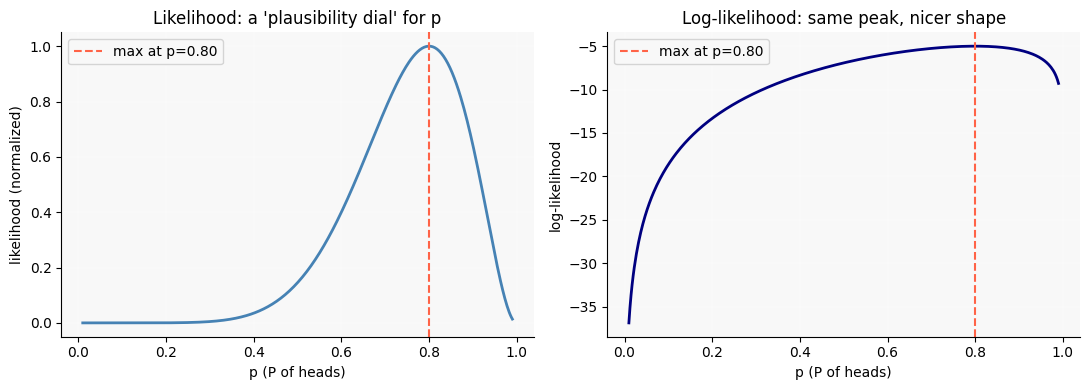

In [2]:
# Verify the coin MLE numerically: data = 8 heads out of 10 flips
n, k = 10, 8
p_grid = np.linspace(0.01, 0.99, 400)
log_like = k * np.log(p_grid) + (n - k) * np.log(1 - p_grid)

p_hat = p_grid[np.argmax(log_like)]
print(f"Numerical MLE  p_hat = {p_hat:.3f}")
print(f"Closed form    k/n   = {k/n:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
likelihood = np.exp(log_like)
ax[0].plot(p_grid, likelihood / likelihood.max(), color=PALETTE[0], lw=2)
ax[0].axvline(k/n, color=PALETTE[1], ls="--", label=f"max at p={k/n:.2f}")
ax[0].set(xlabel="p (P of heads)", ylabel="likelihood (normalized)",
          title="Likelihood: a 'plausibility dial' for p")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(p_grid, log_like, color=PALETTE[4], lw=2)
ax[1].axvline(k/n, color=PALETTE[1], ls="--", label=f"max at p={k/n:.2f}")
ax[1].set(xlabel="p (P of heads)", ylabel="log-likelihood",
          title="Log-likelihood: same peak, nicer shape")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 3 · NLL — Negative Log Likelihood (MLE in disguise as a loss)

Optimizers and ML libraries **minimize**, they don't maximize. So flip the sign:

$$
\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} \sum_i \log p(x_i\mid\theta)
\;\;=\;\;
\arg\min_{\theta} \underbrace{-\sum_i \log p(x_i\mid\theta)}_{\text{NLL} \,=\, \mathcal{L}(\theta)}
$$

> **Key insight:** NLL is not a new concept — it is *literally* MLE with a minus sign so it becomes a loss function. "Minimize the NLL" and "do MLE" are the same sentence. Every time you hear **cross-entropy loss** (classification) or **MSE** (regression), it is an NLL under the hood (Sections 7–8 prove this).

**Analogy:** likelihood measures *how happy the model is*; NLL measures *how surprised* it is. Maximizing happiness = minimizing surprise. "Surprise" is exactly $-\log p$: events the model thought were certain ($p\to1$) cost ~0, events it thought impossible ($p\to0$) cost $\to\infty$.

🎯 **Quant flag:** If an interviewer writes a loss and asks "where does this come from?", the answer is almost always "it's the negative log-likelihood of \<some noise/label distribution\>."

---
## 4 · MAP — Maximum A Posteriori (MLE + a prior = regularization)

MLE listens *only* to the data. With little data it overfits — e.g. flip a coin twice, get two heads, MLE confidently declares $\hat p = 1.0$ (the coin *never* lands tails). That's absurd; you have a **prior belief** that coins are roughly fair.

MAP injects that belief using **Bayes' rule**:

$$
\underbrace{p(\theta \mid \text{data})}_{\text{posterior}} \;\propto\; \underbrace{p(\text{data}\mid\theta)}_{\text{likelihood}} \cdot \underbrace{p(\theta)}_{\text{prior}}
$$

MAP picks the peak of the **posterior** instead of the peak of the likelihood:

$$
\hat{\theta}_{\text{MAP}} = \arg\max_{\theta} \Big[ \sum_i \log p(x_i\mid\theta) + \log p(\theta) \Big]
$$

The only new piece versus MLE is the $\log p(\theta)$ term — a nudge toward parameter values the prior considers reasonable.

> **Key insight (the one to remember): MAP = MLE + regularization.** A Gaussian prior $\theta\sim\mathcal N(0,\tau^2)$ gives $\log p(\theta) = -\frac{1}{2\tau^2}\|\theta\|^2 + \text{const}$, i.e. an **L2 / ridge penalty**. A Laplace prior gives the **L1 / Lasso penalty**. Regularization isn't an ad-hoc trick — it's a prior belief in disguise.

| | Listens to | Extra term | ML name |
|---|---|---|---|
| **MLE** | data only | — | (unregularized fit) |
| **MAP** | data + prior | $\log p(\theta)$ | regularized fit (ridge/lasso) |

As data grows, the likelihood term ($\sum_i$, grows with $n$) drowns out the fixed prior term, so **MAP → MLE in the large-data limit**. The prior matters most when data is scarce.

🎯 **Quant flag:** "What's the Bayesian interpretation of L2 regularization?" → "It's a Gaussian prior on the weights; ridge regression is MAP estimation." This is a beloved interview question.

MLE  p_hat = 0.999   <- 'coin NEVER lands tails' (overfit!)
MAP  p_hat = 0.599   <- pulled toward 0.5 by the fairness prior


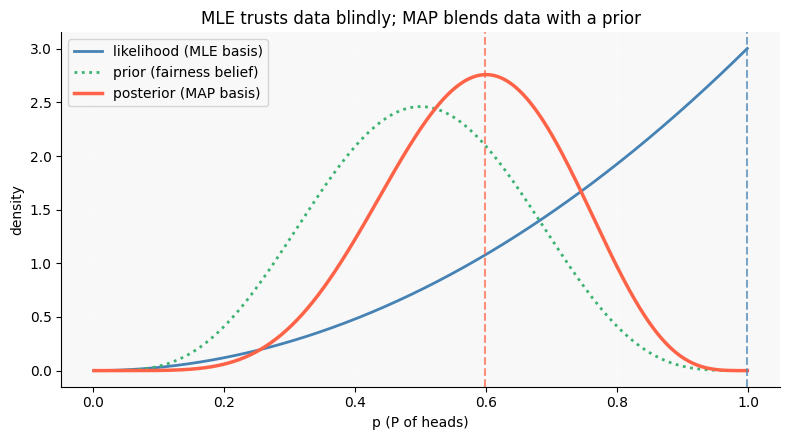

In [3]:
# MLE vs MAP on the coin, with very little data (2 flips, both heads).
# Prior: Beta(a,a) centered at 0.5 -> a 'coins are roughly fair' belief.
n2, k2 = 2, 2          # tiny dataset: 2 heads, 0 tails
a = 5                  # prior strength (pseudo-counts); larger = stronger fairness belief

p = np.linspace(0.001, 0.999, 500)
ll   = k2*np.log(p) + (n2-k2)*np.log(1-p)                 # log-likelihood
lpri = (a-1)*np.log(p) + (a-1)*np.log(1-p)                # log Beta(a,a) prior
lpost = ll + lpri                                          # log-posterior (unnormalized)

p_mle = p[np.argmax(ll)]
p_map = p[np.argmax(lpost)]
print(f"MLE  p_hat = {p_mle:.3f}   <- 'coin NEVER lands tails' (overfit!)")
print(f"MAP  p_hat = {p_map:.3f}   <- pulled toward 0.5 by the fairness prior")

def norm(z):  # turn log-curve into a comparable density for plotting
    z = np.exp(z - z.max()); return z / np.trapezoid(z, p)

plt.figure(figsize=(8, 4.5))
plt.plot(p, norm(ll),    color=PALETTE[0], lw=2, label="likelihood (MLE basis)")
plt.plot(p, norm(lpri),  color=PALETTE[2], lw=2, ls=":", label="prior (fairness belief)")
plt.plot(p, norm(lpost), color=PALETTE[1], lw=2.5, label="posterior (MAP basis)")
plt.axvline(p_mle, color=PALETTE[0], ls="--", alpha=.7)
plt.axvline(p_map, color=PALETTE[1], ls="--", alpha=.7)
plt.xlabel("p (P of heads)"); plt.ylabel("density")
plt.title("MLE trusts data blindly; MAP blends data with a prior")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 5 · ERM — Empirical Risk Minimization (the umbrella)

ERM is the ML community's framing of the *same* optimization. The vocabulary:

- **Risk** = the *true* expected loss over the whole data-generating distribution — what you actually care about, but can't compute (you don't have infinite data).
- **Empirical risk** = the average loss over the data you *do* have. It's the practical stand-in.

$$
\hat{\theta}_{\text{ERM}} = \arg\min_{\theta} \; \underbrace{\frac{1}{n}\sum_{i=1}^{n} \ell\big(y_i, f_\theta(x_i)\big)}_{\text{empirical risk } = \text{ average loss}}
$$

> **Key insight: ERM ⊇ MLE.** If you *choose* the loss to be the negative log-likelihood, $\ell = -\log p(y_i\mid x_i,\theta)$, then ERM **is** MLE (the $\tfrac1n$ is just a constant scale that doesn't move the minimizer). ERM is the bigger box; MLE is the specific choice "loss = NLL." And ERM **+ a penalty term** $\lambda R(\theta)$ is **MAP**. One framework, three names depending on what you plug in.

**Why ERM is the more general view:** ERM lets you pick *any* loss, even ones with no probabilistic story (e.g. the **hinge loss** of an SVM). MLE forces you to commit to a probability model. So: every MLE is an ERM, but not every ERM is an MLE.

### The unifying diagram

```
                    ERM:  min  (1/n) Σ loss(yᵢ, f(xᵢ))   [+ λ·penalty]
                     │                                      │
        pick loss = NLL                              add penalty = log-prior
                     │                                      │
                     ▼                                      ▼
                    MLE  ───────── add prior ───────────▶  MAP
             (max likelihood)                      (max posterior)
```

🎯 **Quant flag:** "Is minimizing MSE the same as maximum likelihood?" Correct answer: "Yes — MSE is the ERM whose loss equals the NLL of a Gaussian-noise model. They give the identical estimator." Section 7 derives it.

---
## 6 · The two scenarios — what actually changes

Everything above is scenario-agnostic. The **only** thing that differs between regression and classification is the **probability distribution you assume for the target $y$** — which in turn fixes the loss (its NLL).

| | **Regression** | **Classification (binary)** |
|---|---|---|
| Target $y$ | continuous (a number) | discrete (0 or 1) |
| Assumed distribution of $y$ | **Gaussian** around prediction | **Bernoulli** with prob = prediction |
| Model output $f_\theta(x)$ | the mean: $\mathbf{w}^\top x$ | a probability: $\sigma(\mathbf{w}^\top x)$ |
| Squash function | none (identity) | **sigmoid** $\sigma$ to map $\mathbb{R}\to(0,1)$ |
| NLL becomes... | **MSE** (squared error) | **BCE** / cross-entropy / log-loss |
| Canonical model | Linear regression | Logistic regression |

> **Key insight:** "Logistic regression" confuses people because it has *regression* in the name but does *classification*. The resolution: it **regresses the probability** of class 1, then thresholds. Same linear core $\mathbf{w}^\top x$ as linear regression — just passed through a sigmoid and paired with the Bernoulli NLL instead of the Gaussian NLL. **Two sister algorithms, one parent recipe.**

The next two sections derive each loss from its distribution, then we implement both with one shared gradient-descent engine to *prove* they're siblings.

---
## 7 · Regression: why MSE *is* maximum likelihood

**Model formulation.** Assume each target is the linear prediction plus Gaussian noise:

$$
y_i = \mathbf{w}^\top x_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)
$$

Equivalently, $y_i \sim \mathcal{N}(\mathbf{w}^\top x_i,\; \sigma^2)$. Plug the Gaussian density into the likelihood:

$$
p(y_i\mid x_i,\mathbf w) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(y_i - \mathbf w^\top x_i)^2}{2\sigma^2}\right)
$$

Take the **negative log** (our NLL), summing over the data:

$$
\text{NLL}(\mathbf w) = \sum_i \left[ \frac{(y_i - \mathbf w^\top x_i)^2}{2\sigma^2} + \tfrac12\log(2\pi\sigma^2)\right]
$$

The second term doesn't depend on $\mathbf w$, and $1/(2\sigma^2)$ is a positive constant. Dropping both (they don't move the minimizer):

$$
\arg\min_{\mathbf w}\, \text{NLL} \;=\; \arg\min_{\mathbf w}\, \sum_i (y_i - \mathbf w^\top x_i)^2 \;=\; \boxed{\text{Mean Squared Error}}
$$

> **Key insight:** MSE falls out of MLE **the moment you assume Gaussian noise**. If you'd assumed a different noise distribution you'd get a different loss (e.g. Laplace noise → MAE / absolute error). MSE is not arbitrary — it encodes the belief "errors are bell-shaped."

### Gradient (needed for descent)
With $\mathcal{L}(\mathbf w) = \frac{1}{n}\sum_i (\,\hat y_i - y_i)^2$ and $\hat y_i = \mathbf w^\top x_i$, the chain rule gives

$$
\nabla_{\mathbf w}\mathcal{L} = \frac{2}{n}\sum_i (\hat y_i - y_i)\, x_i = \frac{2}{n}X^\top(\hat{\mathbf y} - \mathbf y)
$$

🎯 **Quant flag:** "Why squared error and not absolute error?" → "Squared error is the MLE under Gaussian noise; absolute error is the MLE under Laplace noise. Squared also has a unique closed-form solution and a smooth gradient."

In [4]:
# ---- Linear regression via gradient descent (MSE = Gaussian NLL) ----
# Dataset: 1D so we can SEE the fitted line.
N = 80
x_raw = np.linspace(-3, 3, N)
true_w, true_b = 1.7, -0.5
y_reg = true_w * x_raw + true_b + rng.normal(0, 1.0, N)   # Gaussian noise, by construction

X_reg = np.c_[x_raw, np.ones(N)]      # design matrix: [x, 1] so w = [slope, intercept]

def fit_mse(X, y, lr=0.05, epochs=300):
    w = np.zeros(X.shape[1])
    loss_history = []
    n = len(y)
    for _ in range(epochs):
        y_hat = X @ w
        loss = np.mean((y_hat - y) ** 2)          # MSE = Gaussian NLL (up to constants)
        grad = (2 / n) * X.T @ (y_hat - y)        # derived above
        w -= lr * grad
        loss_history.append(loss)
    return w, loss_history

w_reg, hist_reg = fit_mse(X_reg, y_reg)
print(f"Learned  slope={w_reg[0]:.3f}, intercept={w_reg[1]:.3f}")
print(f"True     slope={true_w:.3f}, intercept={true_b:.3f}")
print(f"Final MSE = {hist_reg[-1]:.3f}")

Learned  slope=1.789, intercept=-0.380
True     slope=1.700, intercept=-0.500
Final MSE = 0.904


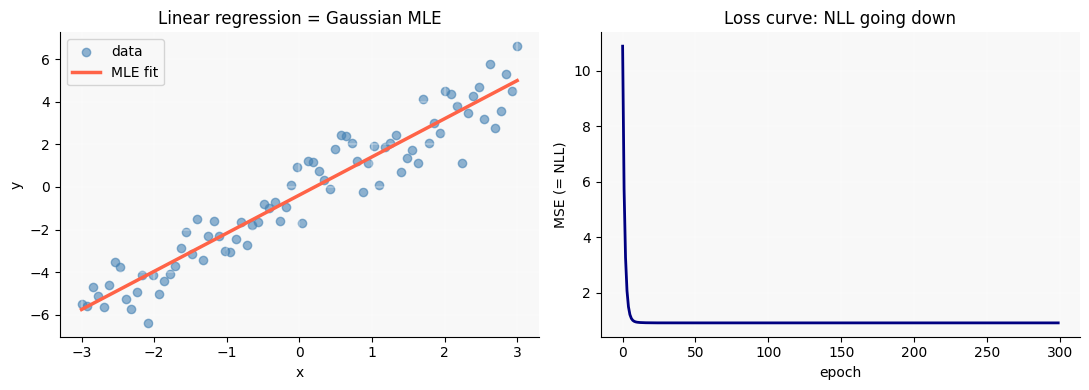

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(x_raw, y_reg, color=PALETTE[0], alpha=0.6, label="data")
ax[0].plot(x_raw, X_reg @ w_reg, color=PALETTE[1], lw=2.5, label="MLE fit")
ax[0].set(xlabel="x", ylabel="y", title="Linear regression = Gaussian MLE")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(hist_reg, color=PALETTE[4], lw=2)
ax[1].set(xlabel="epoch", ylabel="MSE (= NLL)", title="Loss curve: NLL going down")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 8 · Classification: why cross-entropy *is* maximum likelihood

**Model formulation.** The label is 0 or 1, so $y$ is **Bernoulli**. The model outputs the probability of class 1 by squashing the linear score through the **sigmoid** $\sigma(z) = \frac{1}{1+e^{-z}}$ (which maps any real number into $(0,1)$):

$$
\hat{p}_i = \sigma(\mathbf w^\top x_i), \qquad y_i \sim \text{Bernoulli}(\hat p_i)
$$

The Bernoulli probability of a single observed label, written as one slick expression:

$$
p(y_i\mid x_i,\mathbf w) = \hat p_i^{\,y_i}\,(1-\hat p_i)^{\,1-y_i}
$$

(The exponent trick: if $y_i=1$ it reads $\hat p_i$; if $y_i=0$ it reads $1-\hat p_i$.) Negative log, summed = the NLL:

$$
\boxed{\;\mathcal{L}(\mathbf w) = -\frac{1}{n}\sum_i \big[\, y_i\log\hat p_i + (1-y_i)\log(1-\hat p_i)\,\big]\;}
$$

This is the **binary cross-entropy** = **log-loss** = **logistic loss**. Three names, one NLL.

**Reading it as surprise:** if the true label is 1 and the model said $\hat p\approx1$, the term $-\log\hat p\approx0$ (no surprise, no penalty). If it confidently said $\hat p\approx0$, $-\log\hat p\to\infty$ (massive penalty for confident-and-wrong). That asymmetry is exactly what you want.

### Gradient (the famously clean result)
Despite the scary $\log\sigma$ nesting, the sigmoid's derivative $\sigma'=\sigma(1-\sigma)$ causes a beautiful cancellation, leaving:

$$
\nabla_{\mathbf w}\mathcal{L} = \frac{1}{n}\sum_i (\hat p_i - y_i)\,x_i = \frac{1}{n}X^\top(\hat{\mathbf p} - \mathbf y)
$$

> **Key insight:** Look closely — the regression gradient was $\frac{2}{n}X^\top(\hat{\mathbf y}-\mathbf y)$ and the classification gradient is $\frac{1}{n}X^\top(\hat{\mathbf p}-\mathbf y)$. **Identical shape: $X^\top(\text{prediction} - \text{target})$.** The *only* difference is whether "prediction" is the raw $\mathbf w^\top x$ or the sigmoid of it. This is why one gradient-descent loop fits both. They are the same algorithm.

🎯 **Quant flag:** Deriving the logistic-regression gradient and stating it equals $X^\top(\hat p - y)$ is one of the most frequently asked ML derivations in quant interviews. Memorize the $\sigma'=\sigma(1-\sigma)$ step.

In [6]:
# ---- Logistic regression via gradient descent (BCE = Bernoulli NLL) ----
# Same engine shape as fit_mse: prediction - target, times X.
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))   # clip guards against overflow

# Dataset: 2D, two Gaussian blobs -> clearly separable classes.
Nc = 200
X0 = rng.normal([-1.5, -1.5], 1.0, (Nc // 2, 2))   # class 0
X1 = rng.normal([ 1.5,  1.5], 1.0, (Nc // 2, 2))   # class 1
X_cls = np.vstack([X0, X1])
y_cls = np.r_[np.zeros(Nc // 2), np.ones(Nc // 2)]
Xb = np.c_[X_cls, np.ones(Nc)]                     # add bias column

def fit_bce(X, y, lr=0.1, epochs=400):
    w = np.zeros(X.shape[1])
    loss_history = []
    n = len(y)
    eps = 1e-12
    for _ in range(epochs):
        p_hat = sigmoid(X @ w)
        loss = -np.mean(y*np.log(p_hat+eps) + (1-y)*np.log(1-p_hat+eps))  # BCE = NLL
        grad = (1 / n) * X.T @ (p_hat - y)            # note: SAME shape as MSE gradient
        w -= lr * grad
        loss_history.append(loss)
    return w, loss_history

w_cls, hist_cls = fit_bce(Xb, y_cls)
acc = np.mean((sigmoid(Xb @ w_cls) > 0.5) == y_cls)
print(f"Learned weights = {np.round(w_cls, 3)}")
print(f"Final BCE = {hist_cls[-1]:.3f}   |   Accuracy = {acc:.1%}")

Learned weights = [1.808 1.77  0.119]
Final BCE = 0.065   |   Accuracy = 97.0%


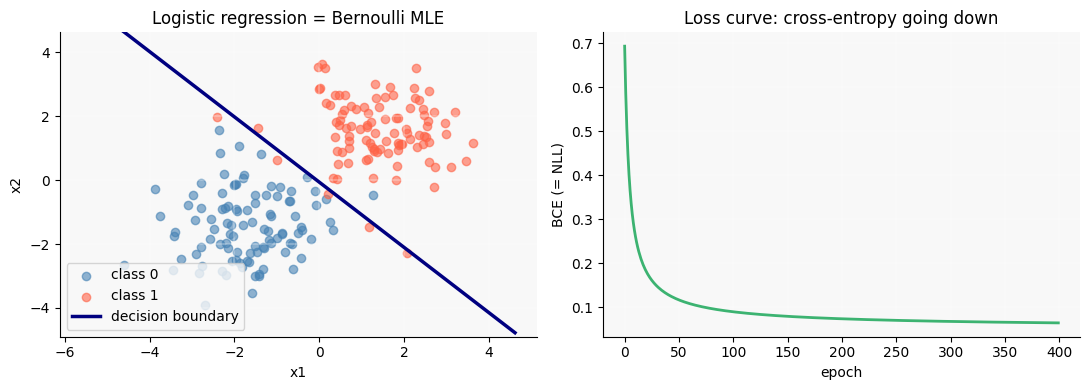

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# decision boundary: where w·x = 0  ->  x2 = -(w0*x1 + b)/w1
xx = np.linspace(X_cls[:,0].min()-1, X_cls[:,0].max()+1, 100)
yy = -(w_cls[0]*xx + w_cls[2]) / w_cls[1]
ax[0].scatter(*X0.T, color=PALETTE[0], alpha=0.6, label="class 0")
ax[0].scatter(*X1.T, color=PALETTE[1], alpha=0.6, label="class 1")
ax[0].plot(xx, yy, color=PALETTE[4], lw=2.5, label="decision boundary")
ax[0].set(xlabel="x1", ylabel="x2", title="Logistic regression = Bernoulli MLE")
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_ylim(X_cls[:,1].min()-1, X_cls[:,1].max()+1)

ax[1].plot(hist_cls, color=PALETTE[2], lw=2)
ax[1].set(xlabel="epoch", ylabel="BCE (= NLL)", title="Loss curve: cross-entropy going down")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 9 · The sigmoid — the bridge between the two scenarios

The *only* structural difference between the two models is the sigmoid squashing $\mathbf w^\top x$ into a probability. Worth seeing on its own:

$$
\sigma(z) = \frac{1}{1+e^{-z}}, \qquad \sigma(0)=0.5, \qquad \sigma'(z) = \sigma(z)\,(1-\sigma(z))
$$

That tidy derivative is *why* the logistic gradient collapsed to $X^\top(\hat p - y)$. The plot below shows the squash and its bell-shaped derivative (steepest, i.e. most sensitive, at $z=0$ where the model is most uncertain).

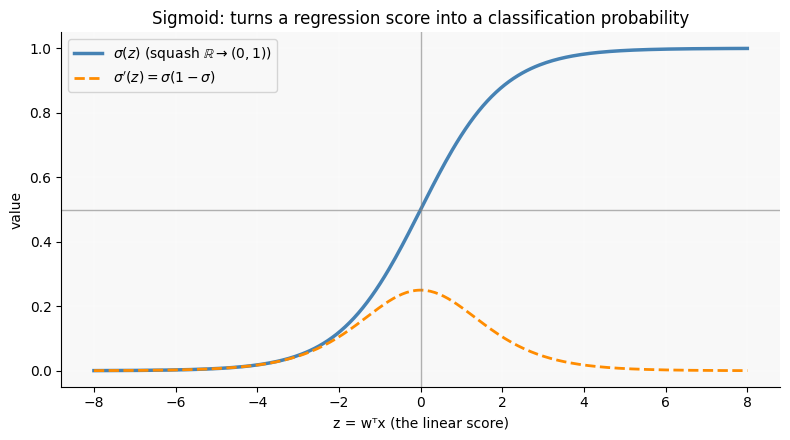

In [8]:
z = np.linspace(-8, 8, 300)
s = sigmoid(z)
plt.figure(figsize=(8, 4.5))
plt.plot(z, s, color=PALETTE[0], lw=2.5, label=r"$\sigma(z)$ (squash $\mathbb{R}\to(0,1)$)")
plt.plot(z, s*(1-s), color=PALETTE[3], lw=2, ls="--", label=r"$\sigma'(z)=\sigma(1-\sigma)$")
plt.axhline(0.5, color="grey", lw=1, alpha=.6)
plt.axvline(0,   color="grey", lw=1, alpha=.6)
plt.xlabel("z = wᵀx (the linear score)"); plt.ylabel("value")
plt.title("Sigmoid: turns a regression score into a classification probability")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 10 · Putting MAP to work: ridge regression as MAP

To make Section 4 concrete in the regression setting: add a Gaussian prior $\mathbf w\sim\mathcal N(0,\tau^2 I)$. The MAP objective is the MSE **plus an L2 penalty** $\lambda\|\mathbf w\|^2$ (with $\lambda = \sigma^2/\tau^2$):

$$
\mathcal{L}_{\text{MAP}}(\mathbf w) = \underbrace{\frac1n\sum_i (\hat y_i - y_i)^2}_{\text{MLE part (data fit)}} + \underbrace{\lambda\|\mathbf w\|^2}_{\text{prior part (shrinkage)}}
$$

Below we fit a wiggly high-degree polynomial to few noisy points. MLE ($\lambda=0$) overfits wildly; MAP ($\lambda>0$) shrinks the weights and smooths the curve — the prior "coins are roughly fair" becomes "the function is roughly simple."

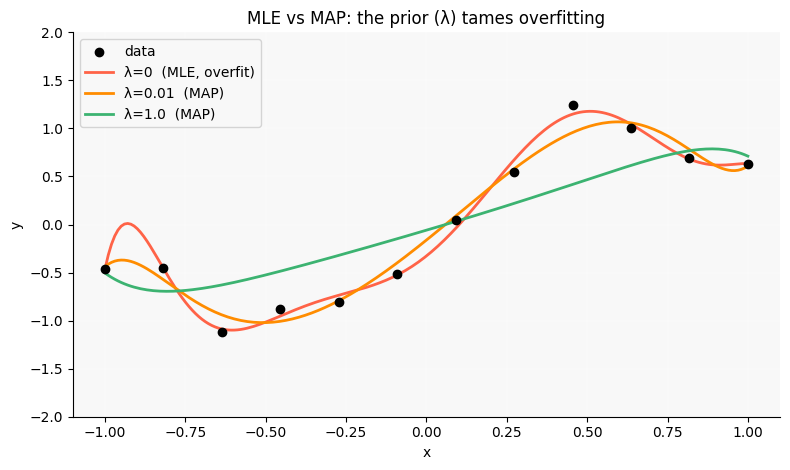

In [9]:
# Few points, high-degree features -> overfitting territory.
Nm = 12
xm = np.linspace(-1, 1, Nm)
ym = np.sin(2.5 * xm) + rng.normal(0, 0.25, Nm)
degree = 9
Phi = np.vander(xm, degree + 1)                  # polynomial design matrix

xs = np.linspace(-1, 1, 200)
Phi_s = np.vander(xs, degree + 1)

def ridge_fit(Phi, y, lam):
    # closed-form MAP solution: (ΦᵀΦ + λI)⁻¹ Φᵀy   (the normal equations + prior)
    A = Phi.T @ Phi + lam * np.eye(Phi.shape[1])
    return np.linalg.solve(A, Phi.T @ y)

plt.figure(figsize=(8, 4.8))
plt.scatter(xm, ym, color="black", zorder=5, label="data")
for lam, c in [(0.0, PALETTE[1]), (1e-2, PALETTE[3]), (1.0, PALETTE[2])]:
    w = ridge_fit(Phi, ym, lam)
    label = ("λ=0  (MLE, overfit)" if lam == 0 else f"λ={lam}  (MAP)")
    plt.plot(xs, Phi_s @ w, color=c, lw=2, label=label)
plt.ylim(-2, 2)
plt.xlabel("x"); plt.ylabel("y")
plt.title("MLE vs MAP: the prior (λ) tames overfitting")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 11 · Interactive: watch the prior strength pull MLE → MAP

Slide $\lambda$ (the regularization / prior strength). At $\lambda=0$ you get pure MLE (overfit); as $\lambda$ grows, MAP shrinks the curve toward simplicity. (If `ipywidgets` isn't installed, the static panel in Section 10 already tells the story.)

In [10]:
try:
    from ipywidgets import interact, FloatLogSlider

    def show(lam=0.0):
        w = ridge_fit(Phi, ym, lam)
        plt.figure(figsize=(7.5, 4.3))
        plt.scatter(xm, ym, color="black", zorder=5, label="data")
        plt.plot(xs, Phi_s @ w, color=PALETTE[1], lw=2.5, label=f"fit (λ={lam:.3g})")
        plt.ylim(-2, 2); plt.xlabel("x"); plt.ylabel("y")
        plt.title(f"‖w‖² = {np.sum(w**2):.1f}   (smaller = simpler = stronger prior)")
        plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    interact(show, lam=FloatLogSlider(value=1e-3, base=10, min=-4, max=1, step=0.25,
                                      description="λ (prior)"))
except Exception as e:
    print("ipywidgets not available — see Section 10's static comparison instead.")
    print(e)

interactive(children=(FloatLogSlider(value=0.001, description='λ (prior)', max=1.0, min=-4.0, step=0.25), Outp…

---
## 12 · Summary

### The four terms

| Concept | Key Idea |
|---|---|
| **Likelihood** $\mathcal L(\theta)$ | Probability of the *observed data* as a function of $\theta$. Data fixed, parameter varies. |
| **MLE** | Pick $\theta$ that maximizes the likelihood. Trusts data only. |
| **NLL** | $-\log$ of the likelihood. The *loss form* of MLE — what you minimize. MSE and cross-entropy are both NLLs. |
| **MAP** | MLE **+ a prior** $\log p(\theta)$. Equals MLE + regularization (Gaussian prior = L2, Laplace = L1). → MLE as data grows. |
| **ERM** | Minimize average loss on the data. The umbrella; MLE = ERM with loss=NLL, MAP = ERM + penalty. |

### The two scenarios

| Concept | Key Idea |
|---|---|
| **Regression** | Assume **Gaussian** noise on $y$ → NLL becomes **MSE**. Model: $\hat y=\mathbf w^\top x$. |
| **Classification** | Assume **Bernoulli** label → NLL becomes **cross-entropy (BCE)**. Model: $\hat p=\sigma(\mathbf w^\top x)$. |
| **Logistic regression** | "Regression" of a *probability*; same linear core as linear regression + sigmoid + Bernoulli NLL. |
| **Shared gradient** | Both reduce to $X^\top(\text{prediction}-\text{target})$ — same descent loop, swap the prediction function. |

### One-paragraph mental model

> Start with **MLE**: make the data least surprising. Write it as a loss by taking $-\log$ → that's the **NLL**, and minimizing average loss is **ERM**. Choose the data distribution and the NLL writes your loss for you: **Gaussian → MSE** (regression), **Bernoulli → cross-entropy** (classification). Add a prior on the parameters and MLE becomes **MAP**, which is just regularization. Four acronyms, one idea.

### 🎯 Quant interview rapid-fire

1. **Probability vs likelihood?** Probability fixes $\theta$, asks about data; likelihood fixes data, asks about $\theta$.
2. **Why MSE for regression?** It's the NLL under Gaussian noise.
3. **Why cross-entropy for classification?** It's the NLL under a Bernoulli label.
4. **Logistic regression gradient?** $X^\top(\hat p - y)$, via $\sigma'=\sigma(1-\sigma)$.
5. **Bayesian view of L2 regularization?** Gaussian prior on weights; ridge = MAP.
6. **MLE vs MAP as $n\to\infty$?** They converge — the likelihood swamps the fixed prior.
7. **Is min-MSE the same as MLE?** Yes, identical estimator under Gaussian noise.